# Esperimenti tesi

Il primo esperimento che voglio fare è fittare una serie di alberi con diverse profondità su dei dati sintetici $y \in \{1,-1\}$ e verificare se la differenza tra l'errore su un training set ($\hat R$) e l'errore su un test set ($R$) segue l'andamento previsto dal bound Prop 2.2, cioè aumenta all'aumentare della profondità del mio albero. 

N.B. parlo di profondità perché nel caso degli alberi, la cardinalità dell'insieme di ipotesi $\mathcal{H}$ è proporzionale alla profondità, in altre parole più profondo l'albero più comlpesso il modello che impariamo. 

## dati


Costruiamo un dataset sintetico di size $n$, secondo la legge 
\begin{gather}
x \sim \mathrm{Unif}(0,10)\\
y \coloneqq \mathrm{sign}(f(x) + \varepsilon), \quad \varepsilon \sim \mathcal{N}(0,1)
\end{gather}
for some $f: X \to Y$ convex. 


In [14]:
# build dataset

import numpy as np

rng = np.random.default_rng(seed=42)  

def sample_x(n, l=0.0, u=10.0, rng=rng):
    """sample n points uniformly on [l, u]"""
    return rng.uniform(l, u, size=n)

def sample_y(x, f, rng=rng):
    """y = g(x) + e, e ~ N(0,1)"""
    e = rng.standard_normal(size=len(x))
    return np.sign(f(x) + e)

In [15]:
# generate dataset

n = 20000         
def f(x):
    return x**2 - 50  # change here to change function (convex)           

x = sample_x(n)
y = sample_y(x, f)


## alberi


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

y_labels = np.sign(y)

X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42
)

n_train = len(X_train)
threshold = np.log2(n_train)  # interpolation threshold

N = 12

# first 12 depths: 1 → threshold, sqrt spacing (decreasing intervals)
depths_before = 1 + (threshold - 1) * np.sqrt(np.arange(N) / (N - 1))

# next 12 depths: threshold → 2*threshold, sqrt spacing (decreasing intervals)
depths_after = threshold + threshold * np.sqrt(np.arange(1, N + 1) / N)

depths_float = np.concatenate([depths_before, depths_after])
depths_int = np.round(depths_float).astype(int)

trees, train_errors, test_errors = [], [], []

for d in depths_int:
    clf = DecisionTreeClassifier(max_depth=int(d), random_state=42)
    clf.fit(X_train, y_train)
    train_errors.append(1 - clf.score(X_train, y_train))
    test_errors.append(1 - clf.score(X_test, y_test))
    trees.append(clf)

print(f"n_train={n_train}, threshold=log2({n_train})={threshold:.3f}")
print()
print(f"{'depth (float)':>13} | {'depth (int)':>10} | {'train error':>11} | {'test error':>10}")
print("-" * 55)
for df, di, tr, te in zip(depths_float, depths_int, train_errors, test_errors):
    print(f"{df:>13.3f} | {di:>10} | {tr:>11.3f} | {te:>10.3f}")


n_train=16000, threshold=log2(16000)=13.966

depth (float) | depth (int) | train error | test error
-------------------------------------------------------
        1.000 |          1 |       0.006 |      0.008
        4.909 |          5 |       0.005 |      0.008
        6.529 |          7 |       0.004 |      0.008
        7.771 |          8 |       0.003 |      0.008
        8.819 |          9 |       0.002 |      0.008
        9.742 |         10 |       0.002 |      0.008
       10.576 |         11 |       0.001 |      0.008
       11.343 |         11 |       0.001 |      0.008
       12.057 |         12 |       0.001 |      0.008
       12.728 |         13 |       0.000 |      0.009
       13.362 |         13 |       0.000 |      0.009
       13.966 |         14 |       0.000 |      0.008
       17.997 |         18 |       0.000 |      0.008
       19.667 |         20 |       0.000 |      0.008
       20.949 |         21 |       0.000 |      0.008
       22.029 |         22 |      

## plot


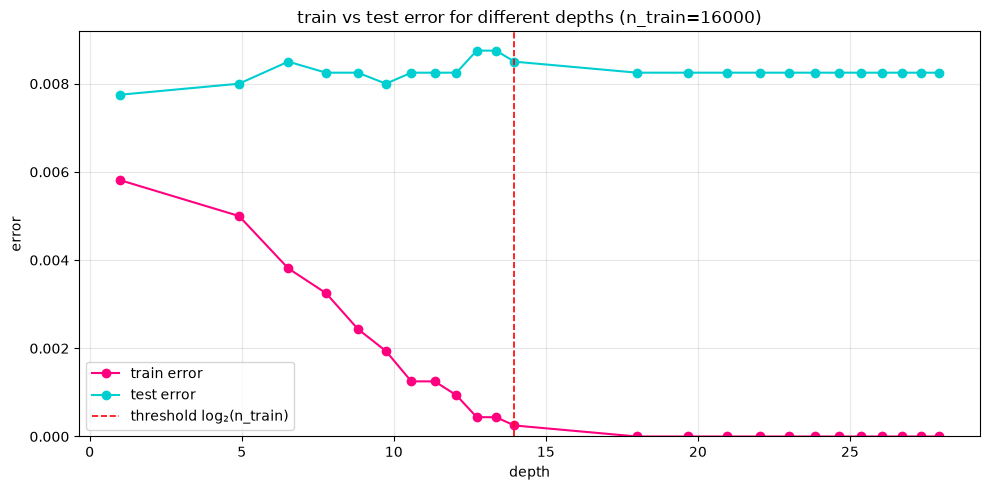

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(depths_float, train_errors, color="#FF007F", marker="o", label="train error")
ax.plot(depths_float, test_errors,  color="#00CED1", marker="o", label="test error")

ax.axvline(threshold, color="red", linestyle="--", linewidth=1.2, label=f"threshold log₂(n_train)")

ax.set_xlabel("depth")
ax.set_ylabel("error")
ax.set_ylim(bottom=0)
ax.set_title(f"train vs test error for different depths (n_train={n_train})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
